In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
import os

print(os.listdir())

['data.ipynb', 'Online Retail.xlsx']


In [1]:
df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully
Rows: 541909
Columns: 8


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
df = df.dropna(subset=["CustomerID"])

print("Rows after removing missing CustomerID:", df.shape[0])
print("Unique customers:", df["CustomerID"].nunique())

Rows after removing missing CustomerID: 406829
Unique customers: 4372


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5225


In [10]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 401604


In [11]:
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

print("Rows after cleaning:", df.shape[0])

Rows after cleaning: 392692


In [12]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].head())

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[us]


In [13]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print(df[["Quantity", "UnitPrice", "TotalAmount"]].head())

   Quantity  UnitPrice  TotalAmount
0         6       2.55        15.30
1         6       3.39        20.34
2         8       2.75        22.00
3         6       3.39        20.34
4         6       3.39        20.34


In [14]:
print("Final rows:", df.shape[0])
print("Unique customers:", df["CustomerID"].nunique())
print("Total sales:", df["TotalAmount"].sum())

Final rows: 392692
Unique customers: 4338
Total sales: 8887208.894000001


In [15]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [16]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [17]:
print("Number of customers:", len(rfm))

Number of customers: 4338


In [18]:
print(rfm.describe())

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


In [19]:
features = ["Recency", "Frequency", "Monetary"]

rfm_features = rfm[features]

print(rfm_features.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [20]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

print("Data standardized successfully")
print(rfm_scaled[:5])

Data standardized successfully
[[ 2.33457414 -0.4250965   8.36301037]
 [-0.90534032  0.3544168   0.2516989 ]
 [-0.17535959 -0.03533985 -0.02798783]
 [-0.73534481 -0.4250965  -0.03240559]
 [ 2.17457836 -0.4250965  -0.19081155]]


In [21]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[9014.566279572977, 5441.323586829659, 4096.300210662249, 3119.78985980015, 2473.7933635647605, 2023.586627223549, 1717.0110430839181, 1468.787102184297, 1281.0480511013268]


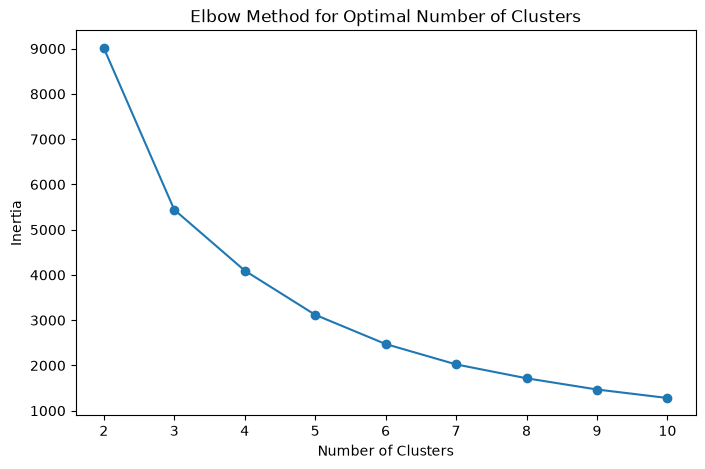

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.show()

In [23]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully")
print(rfm.head())

K-Means clustering completed successfully
            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        3
12347.0           2          7   4310.00        0
12348.0          75          4   1797.24        0
12349.0          19          1   1757.55        0
12350.0         310          1    334.40        1


In [24]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

print("Customers in each cluster:")
print(cluster_counts)

Customers in each cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


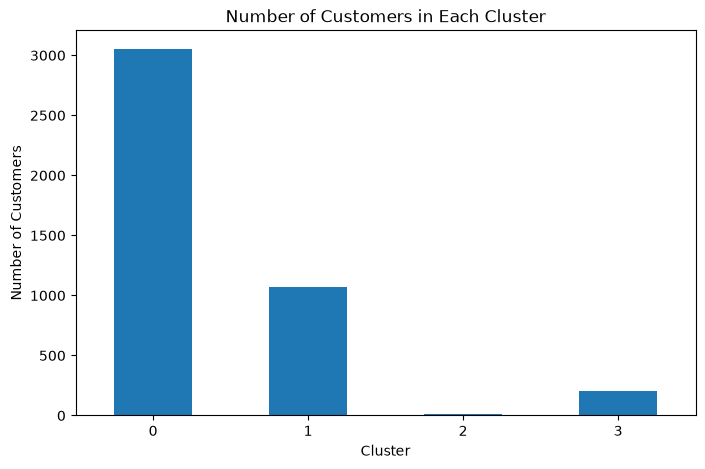

In [25]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind="bar")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [26]:
cluster_profile = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1353.625312
1        248.075914   1.552015     478.848773
2          7.384615  82.538462  127187.959231
3         15.500000  22.333333   12690.500392


In [27]:
cluster_profile = cluster_profile.round(2)

print("Cluster Profile:")
print(cluster_profile)

Cluster Profile:
         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1353.63
1         248.08       1.55     478.85
2           7.38      82.54  127187.96
3          15.50      22.33   12690.50


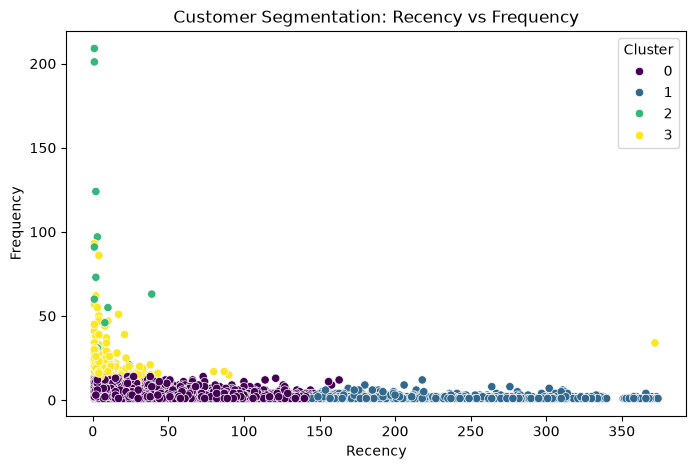

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segmentation: Recency vs Frequency")
plt.xlabel("Recency")
plt.ylabel("Frequency")

plt.show()

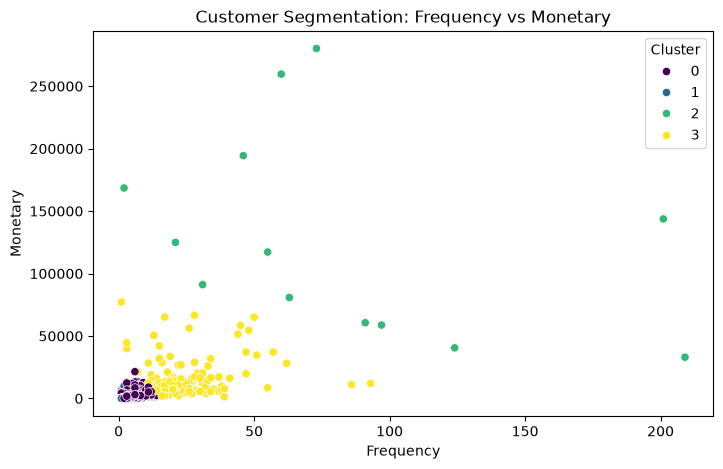

In [29]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segmentation: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

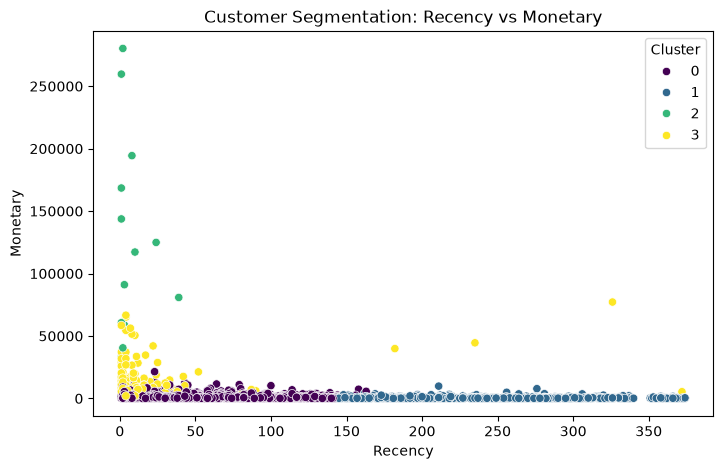

In [30]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segmentation: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.show()

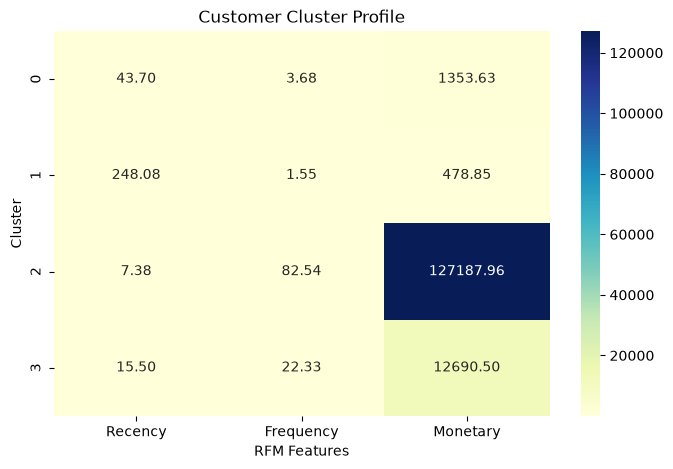

In [31]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Customer Cluster Profile")
plt.xlabel("RFM Features")
plt.ylabel("Cluster")

plt.show()

In [32]:
print(cluster_profile)

         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1353.63
1         248.08       1.55     478.85
2           7.38      82.54  127187.96
3          15.50      22.33   12690.50


In [34]:
segment_names = {
    0: "Regular Customers",
    1: "High Value Customers",
    2: "At Risk Customers",
    3: "New Customers"
}

rfm["CustomerType"] = rfm["Cluster"].map(segment_names)

print(rfm.head())

            Recency  Frequency  Monetary  Cluster          CustomerType
CustomerID                                                             
12346.0         326          1  77183.60        3         New Customers
12347.0           2          7   4310.00        0     Regular Customers
12348.0          75          4   1797.24        0     Regular Customers
12349.0          19          1   1757.55        0     Regular Customers
12350.0         310          1    334.40        1  High Value Customers


In [35]:
customer_type_counts = rfm["CustomerType"].value_counts()

print("Customer Type Distribution:")
print(customer_type_counts)

Customer Type Distribution:
CustomerType
Regular Customers       3054
High Value Customers    1067
New Customers            204
At Risk Customers         13
Name: count, dtype: int64


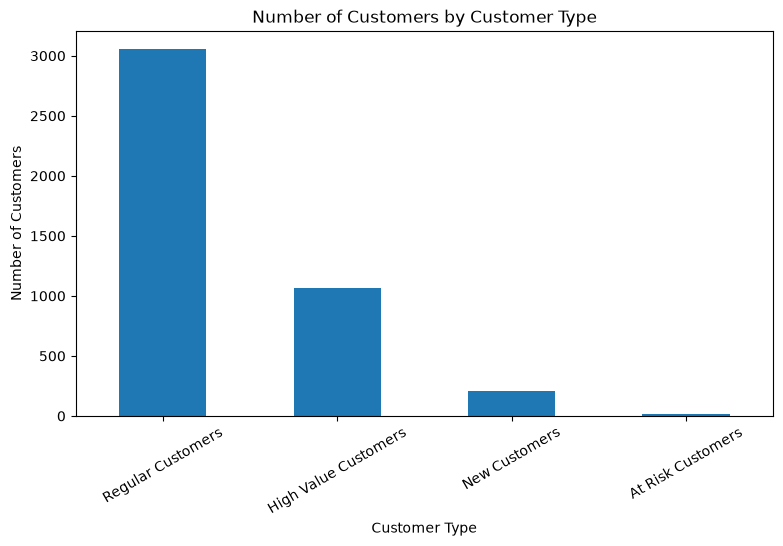

In [36]:
plt.figure(figsize=(9, 5))

customer_type_counts.plot(kind="bar")

plt.title("Number of Customers by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

In [37]:
final_profile = rfm.groupby("CustomerType")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

print("Final Customer Segment Profile:")
print(final_profile)

Final Customer Segment Profile:
                      Recency  Frequency   Monetary
CustomerType                                       
At Risk Customers        7.38      82.54  127187.96
High Value Customers   248.08       1.55     478.85
New Customers           15.50      22.33   12690.50
Regular Customers       43.70       3.68    1353.63


In [38]:
rfm.to_csv("Customer_Segmentation_Result.csv")

print("Customer segmentation results saved successfully")

Customer segmentation results saved successfully


In [39]:
print("========================================")
print(" CUSTOMER SEGMENTATION ANALYSIS")
print("========================================")

print("\nTotal Customers:", len(rfm))

print("\nCustomers in Each Cluster:")
print(cluster_counts)

print("\nCustomer Types:")
print(customer_type_counts)

print("\nFinal Cluster Profile:")
print(final_profile)

print("\nAnalysis completed successfully!")

 CUSTOMER SEGMENTATION ANALYSIS

Total Customers: 4338

Customers in Each Cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

Customer Types:
CustomerType
Regular Customers       3054
High Value Customers    1067
New Customers            204
At Risk Customers         13
Name: count, dtype: int64

Final Cluster Profile:
                      Recency  Frequency   Monetary
CustomerType                                       
At Risk Customers        7.38      82.54  127187.96
High Value Customers   248.08       1.55     478.85
New Customers           15.50      22.33   12690.50
Regular Customers       43.70       3.68    1353.63

Analysis completed successfully!
